В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [49]:
cars_df = pd.read_csv('cars.csv') # замініть на ваш шлях до файлу
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [50]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

Signature:
pd.DataFrame.info(
    self,
    verbose: 'bool | None' = None,
    buf: 'WriteBuffer[str] | None' = None,
    max_cols: 'int | None' = None,
    memory_usage: 'bool | str | None' = None,
    show_counts: 'bool | None' = None,
) -> 'None'
Docstring:
Print a concise summary of a DataFrame.

This method prints information about a DataFrame including
the index dtype and columns, non-null values and memory usage.

Parameters
----------
verbose : bool, optional
    Whether to print the full summary. By default, the setting in
    ``pandas.options.display.max_info_columns`` is followed.
buf : writable buffer, defaults to sys.stdout
    Where to send the output. By default, the output is printed to
    sys.stdout. Pass a writable buffer if you need to further process
    the output.
max_cols : int, optional
    When to switch from the verbose to the truncated output. If the
    DataFrame has more than `max_cols` columns, the truncated output
    is used. By default, the setting in


In [51]:
cars_df.info() #переглянемо типи даних

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [52]:
cars_df.select_dtypes(object) #переглянемо типи даних object

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second
...,...,...,...,...,...
95,Mercedes,C-Class,Diesel,Automatic,First
96,Toyota,Innova Crysta,Diesel,Manual,Second
97,Ford,EcoSport,Petrol,Manual,Third
98,Hyundai,Verna,Petrol,Automatic,Second


In [53]:
cars_df.nunique() #Подивимось унікальні значення для категоріальних змінних

Car_ID               100
Brand                 11
Model                 58
Year                   6
Kilometers_Driven     18
Fuel_Type              2
Transmission           2
Owner_Type             3
Mileage               15
Engine                36
Power                 40
Seats                  3
Price                 31
dtype: int64

В наборі даних 13 колонок. Колонку ID не відносим до будь-якиих ознак (параметрів), її можна трасформувати в тип object. Тож маємо 12 ознак:  7 числових і 5 категоріальних колонок з них:
- 2 бінарні (мають лише 2 значення)-  Fuel_Type, Transmission
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку - Brand, Model
- 1 колонка, в якій можна встановити відношення порядку - Owner_Type

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [76]:
from sklearn.model_selection import train_test_split


In [77]:
X = cars_df.drop("Price", axis=1)
y = cars_df["Price"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12
)


In [79]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape #перевірка пропорції тренувальних та тестових даних


((80, 14), (20, 14), (80,), (20,))

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [80]:
cars_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

In [81]:
Fuel_Type_codes = {'Petrol': 1, 'Diesel': 0}
cars_df['Fuel_Type_codes'] = cars_df.Fuel_Type.map(Fuel_Type_codes)

In [82]:
cars_df["Transmission"].value_counts()

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

In [83]:
Transmission_codes = {'Automatic': 1, 'Manual': 0}
cars_df['Transmission_codes'] = cars_df.Transmission.map(Transmission_codes)

In [84]:
X_train["Fuel_Type_codes"] = cars_df.loc[X_train.index, "Fuel_Type_codes"]
X_test["Fuel_Type_codes"] = cars_df.loc[X_test.index, "Fuel_Type_codes"]

X_train["Transmission_codes"] = cars_df.loc[X_train.index, "Transmission_codes"]
X_test["Transmission_codes"] = cars_df.loc[X_test.index, "Transmission_codes"]

In [85]:
from sklearn.preprocessing import OneHotEncoder

In [86]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [87]:
brand_train = enc.transform(X_train[["Brand"]])
brand_test = enc.transform(X_test[["Brand"]])

In [88]:
brand_train_df = pd.DataFrame(brand_train, columns=brand_cols, index=X_train.index)
brand_test_df = pd.DataFrame(brand_test, columns=brand_cols, index=X_test.index)

In [89]:
X_train = pd.concat([X_train.drop(columns=["Brand"]), brand_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=["Brand"]), brand_test_df], axis=1)


In [90]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [91]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
17,18,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [92]:
numeric_X_train = X_train.select_dtypes(include=['int64', 'float64'])

In [93]:
numeric_X_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [94]:
train_with_target = pd.concat([numeric_X_train, y_train], axis=1)


In [95]:
corr_matrix = train_with_target.corr()
corr_matrix


,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,0.000979
Fuel_Type_codes,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,-0.110782
Transmission_codes,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,0.680731
Brand_Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,0.328858


In [96]:
corr_matrix["Price"].sort_values(ascending=False)


Price                 1.000000
Power                 0.849137
Engine                0.710561
Transmission_codes    0.680731
Brand_BMW             0.477522
Brand_Mercedes        0.431606
Brand_Audi            0.328858
Car_ID                0.025560
Seats                 0.000979
Brand_Ford           -0.004592
Brand_Toyota         -0.023778
Kilometers_Driven    -0.083951
Fuel_Type_codes      -0.110782
Brand_Volkswagen     -0.158742
Brand_Mahindra       -0.178627
Brand_Honda          -0.209779
Year                 -0.233769
Brand_Maruti         -0.249737
Brand_Hyundai        -0.263022
Owner_Type_Codes     -0.265537
Brand_Tata           -0.341815
Mileage              -0.638404
Name: Price, dtype: float64

Змінні, що мають сильну кореляцію з цільовою змінною Price:
Позитивна кореляція:  
– Power (0.85)
– Engine (0.71)
– Transmission_codes (0.68)

Негативна кореляція:  
– Mileage (–0.64)

Це означає, що вища потужність, більший об’єм двигуна та автоматична трансмісія підвищують ціну автомобіля, тоді як великий пробіг суттєво знижує її.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [97]:
numeric_X_test = X_test.select_dtypes(include=['int64', 'float64'])

In [98]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(numeric_X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [99]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_train = model.predict(numeric_X_train)
y_pred_test = model.predict(numeric_X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

rmse_train, rmse_test


(np.float64(210293.5782815184), np.float64(258181.56112033036))

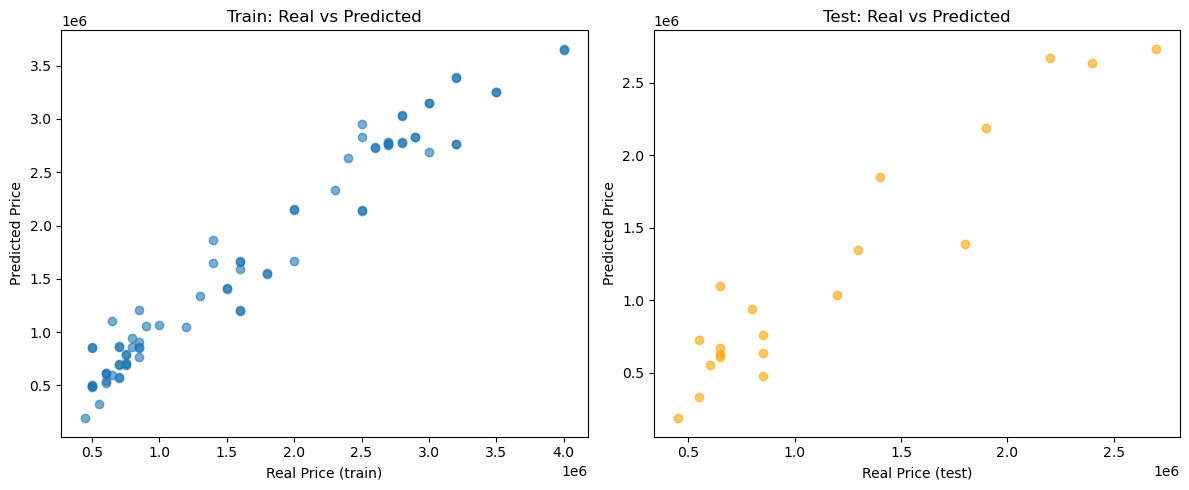

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# TRAIN
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train, alpha=0.6)
plt.xlabel("Real Price (train)")
plt.ylabel("Predicted Price")
plt.title("Train: Real vs Predicted")

# TEST
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='orange')
plt.xlabel("Real Price (test)")
plt.ylabel("Predicted Price")
plt.title("Test: Real vs Predicted")

plt.tight_layout()
plt.show()


In [ ]:
Модель лінійної регресії показує середню якість.  
RMSE на тренувальних даних становить приблизно 210 тис., а на тестових — 258 тис., що свідчить про помірне погіршення якості на нових даних, але без ознак сильного перенавчання.

На графіках розсіювання видно, що передбачення моделі загалом слідують за реальною ціною, але мають значний розкид, особливо для автомобілів з високою вартістю.

Це означає, що лінійна модель вловлює основні залежності, але не здатна точно моделювати складні нелінійні взаємозв’язки в даних.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(numeric_X_train)  # тренуємо тільки на train

X_train_scaled = scaler.transform(numeric_X_train)
X_test_scaled = scaler.transform(numeric_X_test)


In [102]:
X_train_scaled = pd.DataFrame(X_train_scaled, 
                              columns=numeric_X_train.columns, 
                              index=numeric_X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, 
                             columns=numeric_X_test.columns, 
                             index=numeric_X_test.index)

In [103]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
coeffs = pd.Series(model_scaled.coef_, index=X_train_scaled.columns)
coeffs.sort_values(ascending=False)


Power                 496769.214899
Brand_Mercedes        210048.781148
Brand_BMW             208407.313783
Brand_Audi            205600.147769
Transmission_codes    116693.768206
Owner_Type_Codes       42344.952815
Brand_Toyota           15805.701511
Car_ID                  5608.685421
Seats                  -2148.924549
Year                   -8765.645714
Engine                -21377.453338
Brand_Honda           -62753.005386
Brand_Tata            -65996.246972
Brand_Volkswagen      -92968.260065
Kilometers_Driven     -94398.721486
Brand_Maruti         -112259.967020
Brand_Ford           -118209.450311
Mileage              -131715.512030
Brand_Mahindra       -140945.162904
Brand_Hyundai        -152304.863911
Fuel_Type_codes      -183848.018909
dtype: float64

Найвпливовішими змінними в моделі є Power, Fuel_Type_codes, Mileage, Transmission_codes та преміальні бренди (Mercedes, BMW, Audi).

Позитивні коефіцієнти (Power, преміальні бренди, автоматична трансмісія) означають, що збільшення цих характеристик підвищує ціну автомобіля. Це логічно, оскільки потужніші авто з автоматичною коробкою передач та преміальним брендом зазвичай дорожчі.

Негативні коефіцієнти (Mileage, Kilometers_Driven, бюджетні бренди, Fuel_Type_codes) означають, що збільшення пробігу або належність до бюджетного бренду знижує ціну. Це також відповідає реальній ринковій поведінці.

Таким чином, модель підтверджує певні  залежності між характеристиками автомобіля та його ринковою вартістю.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [106]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)
model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.01e-33
Time:                        22:22:49   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.74

На рівні значущості 0.05 статистично значущими є такі ознаки:
Power, Fuel_Type_codes, Transmission_codes, Mileage, Brand_Audi, Brand_BMW, Brand_Ford, Brand_Hyundai, Brand_Mahindra, Brand_Maruti, Brand_Mercedes, Brand_Volkswagen.

Це означає, що саме ці характеристики мають  вплив на ціну автомобіля. 

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [107]:
significant_features = [
    "Power",
    "Fuel_Type_codes",
    "Transmission_codes",
    "Mileage",
    "Brand_Audi",
    "Brand_BMW",
    "Brand_Ford",
    "Brand_Hyundai",
    "Brand_Mahindra",
    "Brand_Maruti",
    "Brand_Mercedes",
    "Brand_Volkswagen"
]

X_train_sig = X_train_scaled[significant_features]


In [108]:
import statsmodels.api as sm

X_train_sig_sm = sm.add_constant(X_train_sig)
model_sig = sm.OLS(y_train, X_train_sig_sm).fit()

print(model_sig.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        22:26:42   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.78

Після тренування моделі лише на статистично значущих ознаках значення R² та Adj. R² практично не змінилися.
Нова модель має R² = 0.951 та Adj. R² = 0.943, що дуже близько до попередніх значень (0.959 та 0.945).
Це означає, що видалення незначущих ознак не погіршило якість моделі, а навпаки — зробило її компактнішою.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [109]:
features_p25 = [
    "Power",
    "Fuel_Type_codes",
    "Transmission_codes",
    "Mileage",
    "Brand_Audi",
    "Brand_BMW",
    "Brand_Ford",
    "Brand_Hyundai",
    "Brand_Mahindra",
    "Brand_Maruti",
    "Brand_Mercedes",
    "Brand_Volkswagen",
    "Kilometers_Driven",
    "Brand_Honda",
    "Brand_Tata"
]


In [110]:
X_train_p25 = X_train_scaled[features_p25]
X_train_p25_sm = sm.add_constant(X_train_p25)

model_p25 = sm.OLS(y_train, X_train_p25_sm).fit()
print(model_p25.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        22:30:51   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.65

Модель із ознаками p < 0.25 зберігає високу якість (R² ≈ 0.958, Adj. R² ≈ 0.948) і водночас залишається компактною.
Вона пояснює майже стільки ж варіації ціни, як і повна модель, але без зайвих незначущих змінних.

Отже, для практичного використання найкраще залишити саме цю модель (з p < 0.25) — вона оптимально балансує точність, інтерпретованість і стабільність.